In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df = pd.read_csv('/Users/sasanbayani/Downloads/Employee_Attrition_Project_Dataset.csv')

In [3]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany
0,1,58,Male,5.0,3,61401,45,HR,1
1,2,48,Female,14.0,5,101831,57,HR,0
2,3,34,Female,0.1,2,149503,31,Finance,0
3,4,27,Male,3.4,4,145760,40,Finance,1
4,5,40,Female,5.5,2,131529,39,Finance,0
...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0
496,497,28,Male,14.4,2,129084,52,IT,1
497,498,26,Female,7.0,2,138212,38,HR,0
498,499,47,Male,13.2,1,69071,44,Finance,0


EXPLORING IN DATAFRAME

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployeeID       500 non-null    int64  
 1   Age              500 non-null    int64  
 2   Gender           500 non-null    object 
 3   Tenure           500 non-null    float64
 4   JobSatisfaction  500 non-null    int64  
 5   Salary           500 non-null    int64  
 6   WeeklyHours      500 non-null    int64  
 7   Department       500 non-null    object 
 8   LeftCompany      500 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 35.3+ KB


In [5]:
df.describe()

,EmployeeID,Age,Tenure,JobSatisfaction,Salary,WeeklyHours,LeftCompany
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,40.436000,7.786600,3.030000,91291.322000,45.148000,0.272000
std,144.481833,11.656142,4.343032,1.421669,34360.576551,8.404723,0.445436
min,1.000000,20.000000,0.000000,1.000000,30163.000000,30.000000,0.000000
25%,125.750000,31.000000,4.100000,2.000000,61392.500000,38.000000,0.000000
50%,250.500000,42.000000,7.950000,3.000000,90933.000000,46.000000,0.000000
75%,375.250000,51.000000,11.525000,4.000000,122339.500000,52.250000,1.000000
max,500.000000,59.000000,15.000000,5.000000,149979.000000,59.000000,1.000000


In [6]:
df.isnull().sum()

EmployeeID         0
Age                0
Gender             0
Tenure             0
JobSatisfaction    0
Salary             0
WeeklyHours        0
Department         0
LeftCompany        0
dtype: int64

In [7]:
df.value_counts()

EmployeeID  Age  Gender  Tenure  JobSatisfaction  Salary  WeeklyHours  Department  LeftCompany
1           58   Male    5.0     3                61401   45           HR          1              1
330         44   Female  0.0     4                129853  42           Sales       1              1
343         47   Female  9.6     2                133141  56           IT          0              1
342         34   Male    11.4    3                146981  30           IT          0              1
341         42   Female  14.4    1                36548   47           Operations  1              1
                                                                                                 ..
162         52   Female  1.7     2                148413  36           Sales       0              1
161         56   Male    9.1     2                49169   37           IT          1              1
160         28   Female  11.8    2                39715   51           Sales       0              1
159  

In [8]:
df['Salary'].describe()

count       500.000000
mean      91291.322000
std       34360.576551
min       30163.000000
25%       61392.500000
50%       90933.000000
75%      122339.500000
max      149979.000000
Name: Salary, dtype: float64

In [9]:
df.drop('EmployeeID', axis=True)

,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany
0,58,Male,5.0,3,61401,45,HR,1
1,48,Female,14.0,5,101831,57,HR,0
2,34,Female,0.1,2,149503,31,Finance,0
3,27,Male,3.4,4,145760,40,Finance,1
4,40,Female,5.5,2,131529,39,Finance,0
...,...,...,...,...,...,...,...,...
495,31,Female,13.2,1,89765,37,Finance,0
496,28,Male,14.4,2,129084,52,IT,1
497,26,Female,7.0,2,138212,38,HR,0
498,47,Male,13.2,1,69071,44,Finance,0


FEATURE ENGINEERIG

In [10]:
df['min_salary'] = df.groupby('Department')['Salary'].transform('min')
df['max_salary'] = df.groupby('Department')['Salary'].transform('max')
df['avg_salary'] = df.groupby('Department')['Salary'].transform('mean')

In [11]:
df['Age'].describe()


count    500.000000
mean      40.436000
std       11.656142
min       20.000000
25%       31.000000
50%       42.000000
75%       51.000000
max       59.000000
Name: Age, dtype: float64

In [12]:
def age_class(a):
    if a < 30:
         return 'Young'
    elif  30 <=  a < 45: 
         return 'middle'
    elif    45 <= a < 60:
      return 'older adults'
    
    


In [13]:
df['age_class'] = df['Age'].apply(age_class)

In [14]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,min_salary,max_salary,avg_salary,age_class
0,1,58,Male,5.0,3,61401,45,HR,1,30207,145463,85183.675676,older adults
1,2,48,Female,14.0,5,101831,57,HR,0,30207,145463,85183.675676,older adults
2,3,34,Female,0.1,2,149503,31,Finance,0,35542,149863,95530.541284,middle
3,4,27,Male,3.4,4,145760,40,Finance,1,35542,149863,95530.541284,Young
4,5,40,Female,5.5,2,131529,39,Finance,0,35542,149863,95530.541284,middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0,35542,149863,95530.541284,middle
496,497,28,Male,14.4,2,129084,52,IT,1,30661,149968,87765.539216,Young
497,498,26,Female,7.0,2,138212,38,HR,0,30207,145463,85183.675676,Young
498,499,47,Male,13.2,1,69071,44,Finance,0,35542,149863,95530.541284,older adults


In [15]:
df['Tenure'].describe()

count    500.000000
mean       7.786600
std        4.343032
min        0.000000
25%        4.100000
50%        7.950000
75%       11.525000
max       15.000000
Name: Tenure, dtype: float64

In [16]:
def tenure_class(x):
    if x < 5 :
        return 'Junior'
    elif 5 < x < 10 :
        return 'Senior'
    elif 10 <= x <= 15:
        return 'Cheff'
    else:
        return 'out of range'
    

In [17]:
df['tenure_class'] = df['Tenure'].apply(tenure_class)

In [18]:
df['WeeklyHours'].describe()

def worktime_org(b):
    if b <= 40:
      return 'Ideal'
    elif 40 <= b < 50:
       return 'Normal Time'
    elif 50 <= b < 60:
        return 'over worked'

In [19]:
df['worktime_type'] = df['WeeklyHours'].apply(worktime_org) 

In [20]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,min_salary,max_salary,avg_salary,age_class,tenure_class,worktime_type
0,1,58,Male,5.0,3,61401,45,HR,1,30207,145463,85183.675676,older adults,out of range,Normal Time
1,2,48,Female,14.0,5,101831,57,HR,0,30207,145463,85183.675676,older adults,Cheff,over worked
2,3,34,Female,0.1,2,149503,31,Finance,0,35542,149863,95530.541284,middle,Junior,Ideal
3,4,27,Male,3.4,4,145760,40,Finance,1,35542,149863,95530.541284,Young,Junior,Ideal
4,5,40,Female,5.5,2,131529,39,Finance,0,35542,149863,95530.541284,middle,Senior,Ideal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0,35542,149863,95530.541284,middle,Cheff,Ideal
496,497,28,Male,14.4,2,129084,52,IT,1,30661,149968,87765.539216,Young,Cheff,over worked
497,498,26,Female,7.0,2,138212,38,HR,0,30207,145463,85183.675676,Young,Senior,Ideal
498,499,47,Male,13.2,1,69071,44,Finance,0,35542,149863,95530.541284,older adults,Cheff,Normal Time


In [21]:
df.describe()

,EmployeeID,Age,Tenure,JobSatisfaction,Salary,WeeklyHours,LeftCompany,min_salary,max_salary,avg_salary
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,40.436000,7.786600,3.030000,91291.322000,45.148000,0.272000,32511.786000,149166.760000,91291.322000
std,144.481833,11.656142,4.343032,1.421669,34360.576551,8.404723,0.445436,2507.258115,1559.130623,3760.236745
min,1.000000,20.000000,0.000000,1.000000,30163.000000,30.000000,0.000000,30163.000000,145463.000000,85183.675676
25%,125.750000,31.000000,4.100000,2.000000,61392.500000,38.000000,0.000000,30207.000000,149425.000000,87765.539216
50%,250.500000,42.000000,7.950000,3.000000,90933.000000,46.000000,0.000000,30661.000000,149863.000000,91426.954545
75%,375.250000,51.000000,11.525000,4.000000,122339.500000,52.250000,1.000000,35249.000000,149968.000000,94478.000000
max,500.000000,59.000000,15.000000,5.000000,149979.000000,59.000000,1.000000,35542.000000,149979.000000,95530.541284


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployeeID       500 non-null    int64  
 1   Age              500 non-null    int64  
 2   Gender           500 non-null    object 
 3   Tenure           500 non-null    float64
 4   JobSatisfaction  500 non-null    int64  
 5   Salary           500 non-null    int64  
 6   WeeklyHours      500 non-null    int64  
 7   Department       500 non-null    object 
 8   LeftCompany      500 non-null    int64  
 9   min_salary       500 non-null    int64  
 10  max_salary       500 non-null    int64  
 11  avg_salary       500 non-null    float64
 12  age_class        500 non-null    object 
 13  tenure_class     500 non-null    object 
 14  worktime_type    500 non-null    object 
dtypes: float64(2), int64(8), object(5)
memory usage: 58.7+ KB


Salary Per Hour ===>

In [23]:
df['salary_per_hour'] = df['Salary'] / (df['WeeklyHours'] * 52)

In [24]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,min_salary,max_salary,avg_salary,age_class,tenure_class,worktime_type,salary_per_hour
0,1,58,Male,5.0,3,61401,45,HR,1,30207,145463,85183.675676,older adults,out of range,Normal Time,26.239744
1,2,48,Female,14.0,5,101831,57,HR,0,30207,145463,85183.675676,older adults,Cheff,over worked,34.355938
2,3,34,Female,0.1,2,149503,31,Finance,0,35542,149863,95530.541284,middle,Junior,Ideal,92.743797
3,4,27,Male,3.4,4,145760,40,Finance,1,35542,149863,95530.541284,Young,Junior,Ideal,70.076923
4,5,40,Female,5.5,2,131529,39,Finance,0,35542,149863,95530.541284,middle,Senior,Ideal,64.856509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0,35542,149863,95530.541284,middle,Cheff,Ideal,46.655405
496,497,28,Male,14.4,2,129084,52,IT,1,30661,149968,87765.539216,Young,Cheff,over worked,47.738166
497,498,26,Female,7.0,2,138212,38,HR,0,30207,145463,85183.675676,Young,Senior,Ideal,69.945344
498,499,47,Male,13.2,1,69071,44,Finance,0,35542,149863,95530.541284,older adults,Cheff,Normal Time,30.188374


**Salary to avg department ===>**


In [25]:
df['Salary_avg_department'] = df['Salary'] / df.groupby('Department')['Salary'].transform('mean')

Salary Gap from Max Salary 

In [26]:
df['Salary_gap_to_max'] = df['max_salary'] - df['Salary']

In [27]:
df['satisfaction_norm'] = df['JobSatisfaction'] / 5

In [28]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,min_salary,max_salary,avg_salary,age_class,tenure_class,worktime_type,salary_per_hour,Salary_avg_department,Salary_gap_to_max,satisfaction_norm
0,1,58,Male,5.0,3,61401,45,HR,1,30207,145463,85183.675676,older adults,out of range,Normal Time,26.239744,0.720807,84062,0.6
1,2,48,Female,14.0,5,101831,57,HR,0,30207,145463,85183.675676,older adults,Cheff,over worked,34.355938,1.195429,43632,1.0
2,3,34,Female,0.1,2,149503,31,Finance,0,35542,149863,95530.541284,middle,Junior,Ideal,92.743797,1.564976,360,0.4
3,4,27,Male,3.4,4,145760,40,Finance,1,35542,149863,95530.541284,Young,Junior,Ideal,70.076923,1.525795,4103,0.8
4,5,40,Female,5.5,2,131529,39,Finance,0,35542,149863,95530.541284,middle,Senior,Ideal,64.856509,1.376827,18334,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0,35542,149863,95530.541284,middle,Cheff,Ideal,46.655405,0.939647,60098,0.2
496,497,28,Male,14.4,2,129084,52,IT,1,30661,149968,87765.539216,Young,Cheff,over worked,47.738166,1.470782,20884,0.4
497,498,26,Female,7.0,2,138212,38,HR,0,30207,145463,85183.675676,Young,Senior,Ideal,69.945344,1.622517,7251,0.4
498,499,47,Male,13.2,1,69071,44,Finance,0,35542,149863,95530.541284,older adults,Cheff,Normal Time,30.188374,0.723025,80792,0.2


<Axes: ylabel='count'>

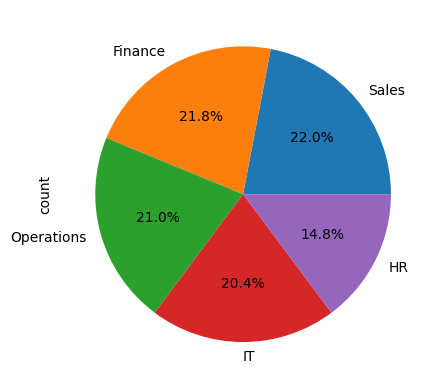

In [29]:
df['Department'].value_counts().plot(kind='pie', color='Black',autopct='%1.1f%%')

<Axes: xlabel='age_class'>

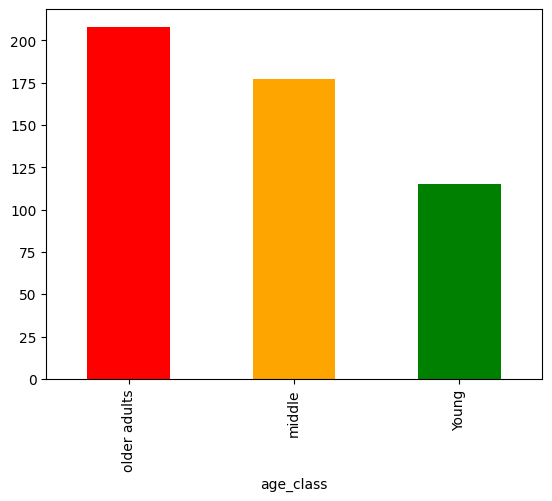

In [30]:
df['age_class'].value_counts().plot(kind='bar', color=['red','orange','green'])

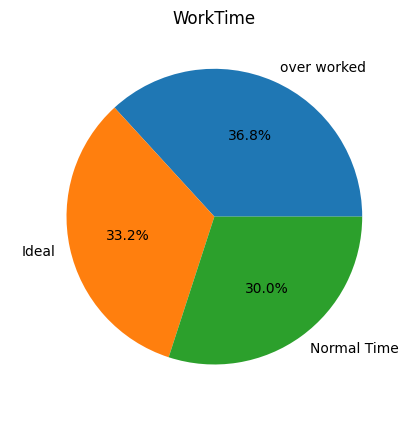

In [31]:
df['worktime_type'].value_counts().plot(kind='pie', color=('red','orange','green'),autopct='%1.1f%%')
plt.xlabel(' ')
plt.title('WorkTime')
plt.ylabel(' ')
plt.show()


<Axes: xlabel='Gender'>

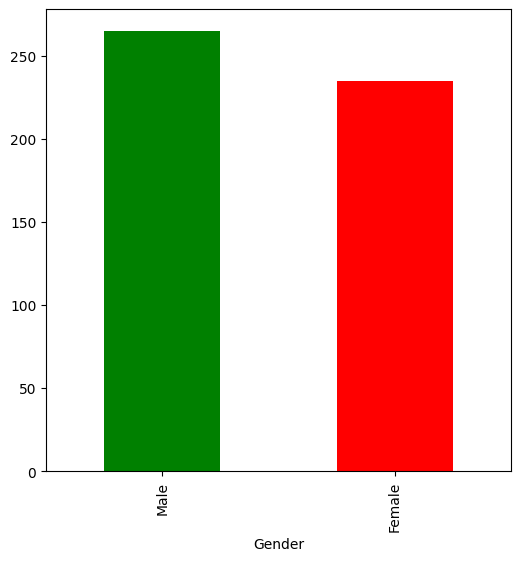

In [32]:
df['Gender'].value_counts().plot(kind='bar',color=['green','red'] ,figsize=(6,6))

visualation

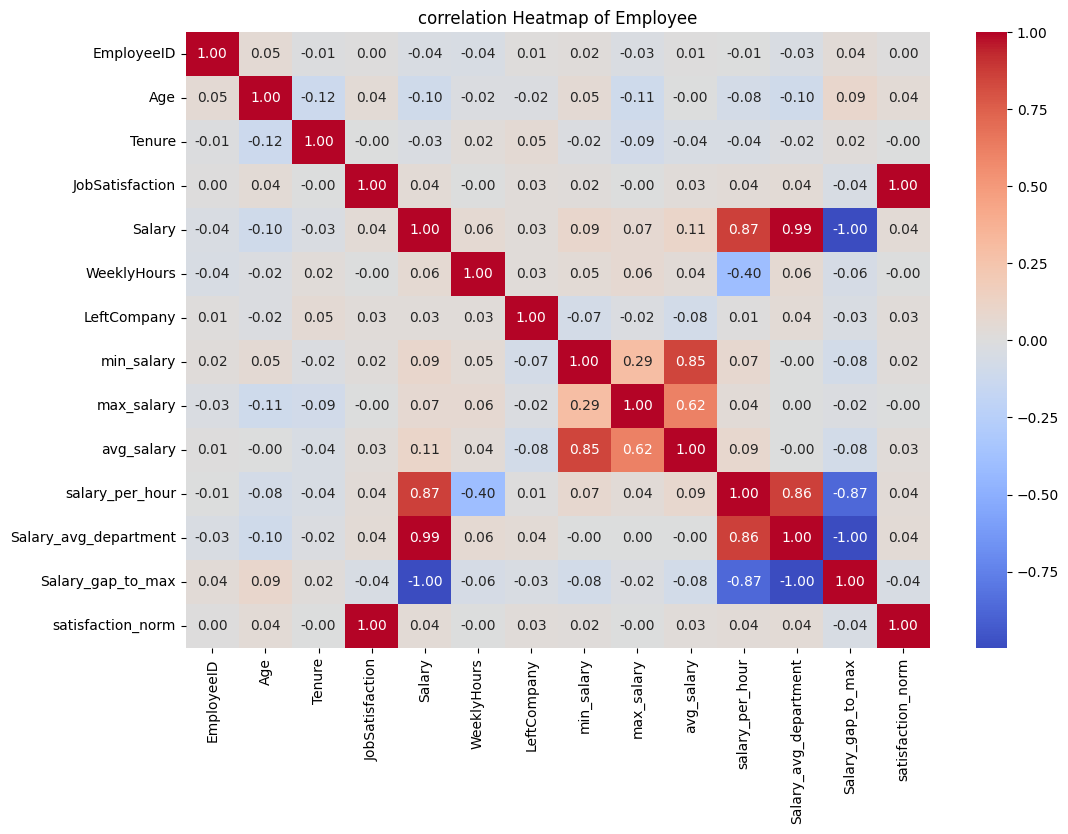

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation Heatmap of Employee')
plt.show()

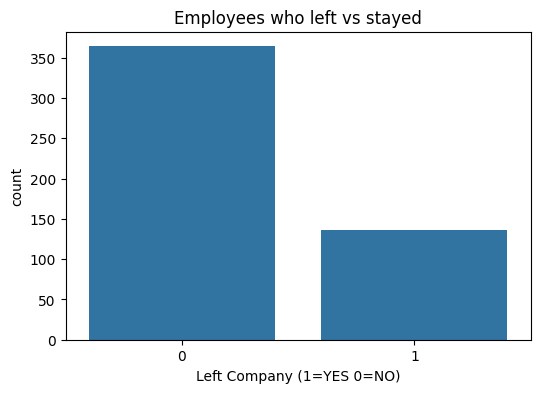

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='LeftCompany', data=df)
plt.title('Employees who left vs stayed')
plt.xlabel('Left Company (1=YES 0=NO)')
plt.show()


LEFT COMPANY BY DEPARTMENT

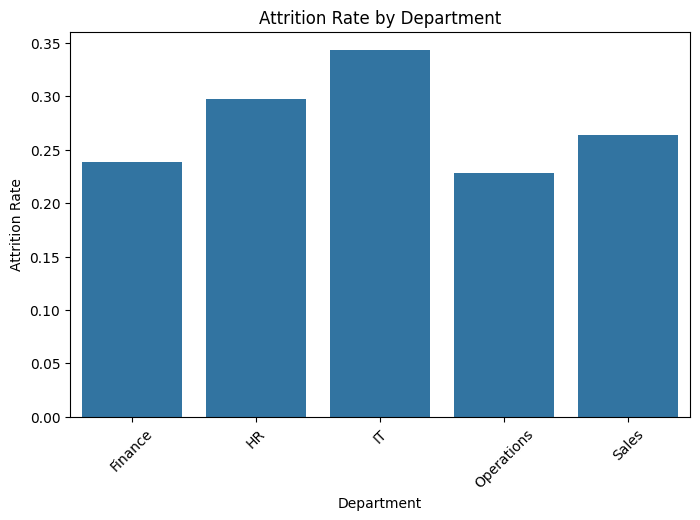

In [35]:
attrition_by_dept = df.groupby('Department')['LeftCompany'].mean().reset_index()
plt.figure(figsize=(8,5),)
sns.barplot(data=attrition_by_dept, x='Department', y='LeftCompany')
plt.title('Attrition Rate by Department')
plt.xticks(rotation=45)
plt.ylabel('Attrition Rate')
plt.show()

Age Rate vs Left Company

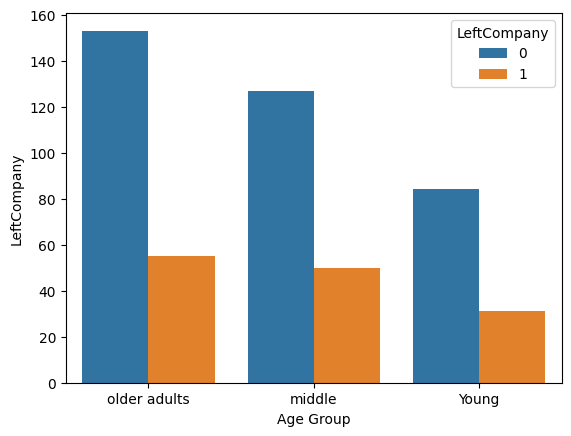

In [36]:
plt.Figure(figsize=(8,6))
sns.countplot(data=df, x='age_class', hue='LeftCompany')
plt.xlabel('Age Group')
plt.ylabel('LeftCompany')
plt.show()

<Axes: xlabel='Tenure', ylabel='Salary'>

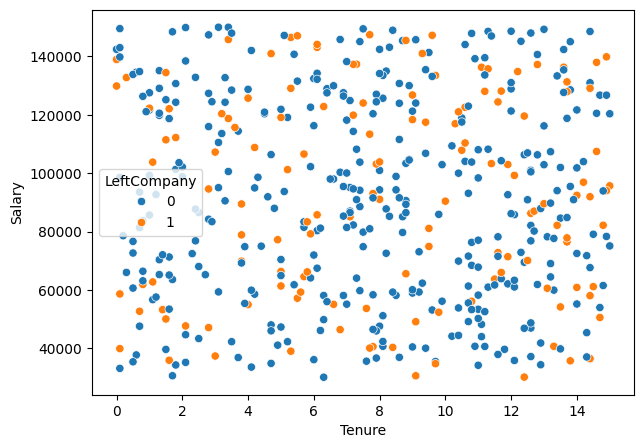

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Tenure', y='Salary', hue='LeftCompany')


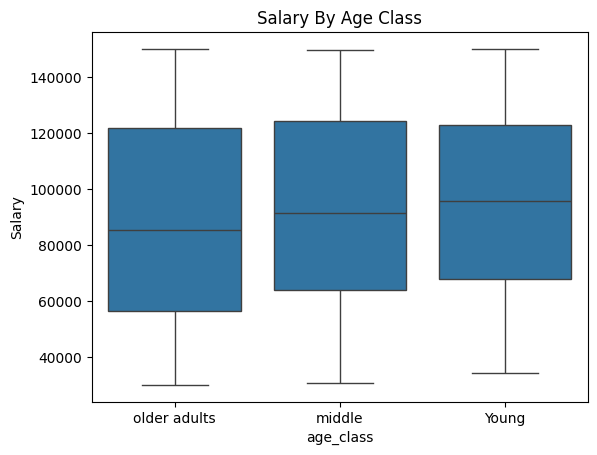

In [38]:
plt.Figure(figsize=(8,6))
sns.boxplot(data=df,x='age_class', y='Salary')
plt.title('Salary By Age Class')
plt.show()

Machine Learning 

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report



Random Forest

In [40]:
x=df.drop('LeftCompany', axis=1)
y= df['LeftCompany']
x = pd.get_dummies(x, columns=['Gender','Department','age_class','tenure_class','worktime_type',], dtype=int,drop_first=True)

In [41]:
x_tarin, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.ensemble import RandomForestClassifier
random = RandomForestClassifier()
random.fit(x_tarin,y_train)
random_predict= random.predict(x_test)


In [43]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

In [44]:
random_predict

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [45]:
confusion_matrix(y_test,random_predict)

array([[65,  6],
       [29,  0]])

In [46]:
accuracy_score(y_test,random_predict,normalize=False)


65.0

In [47]:
accuracy_score(y_test,random_predict,normalize=True)

0.65

In [48]:
print(classification_report(y_test,random_predict))

              precision    recall  f1-score   support

           0       0.69      0.92      0.79        71
           1       0.00      0.00      0.00        29

    accuracy                           0.65       100
   macro avg       0.35      0.46      0.39       100
weighted avg       0.49      0.65      0.56       100



KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [50]:
knn = KNeighborsClassifier()
knn.fit(x_tarin,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
knn_predict = knn.predict(x_test)

In [52]:
knn_predict

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [53]:
confusion_matrix(y_test,knn_predict)

array([[64,  7],
       [28,  1]])

In [54]:
accuracy_score(y_test,knn_predict,normalize=True)

0.65

In [55]:
accuracy_score(y_test,knn_predict,normalize=False)

65.0

In [56]:
print(classification_report(y_test,knn_predict))

              precision    recall  f1-score   support

           0       0.70      0.90      0.79        71
           1       0.12      0.03      0.05        29

    accuracy                           0.65       100
   macro avg       0.41      0.47      0.42       100
weighted avg       0.53      0.65      0.57       100



Decision TreeClassifire

In [57]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()

In [58]:
tree.fit(x_tarin,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
tree_predict = tree.predict(x_test)

In [60]:
tree_predict

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0])

In [61]:
confusion_matrix(y_test,tree_predict)

array([[42, 29],
       [27,  2]])

In [62]:
accuracy_score(y_test,knn_predict)

0.65

In [63]:
print(classification_report(y_test,knn_predict))

              precision    recall  f1-score   support

           0       0.70      0.90      0.79        71
           1       0.12      0.03      0.05        29

    accuracy                           0.65       100
   macro avg       0.41      0.47      0.42       100
weighted avg       0.53      0.65      0.57       100



In [64]:
from sklearn.svm import SVC

In [65]:
svm = SVC()

In [66]:
svm.fit(x_tarin,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
svm_predict = svm.predict(x_test)

In [68]:
svm_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [69]:
confusion_matrix(y_test,svm_predict)

array([[71,  0],
       [29,  0]])

In [70]:
accuracy_score(y_test,svm_predict,normalize=True)

0.71

In [71]:
accuracy_score(y_test,svm_predict,normalize=False)

71.0

In [72]:
print(classification_report(y_test,svm_predict))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        71
           1       0.00      0.00      0.00        29

    accuracy                           0.71       100
   macro avg       0.35      0.50      0.42       100
weighted avg       0.50      0.71      0.59       100



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

CATBOOST MODEL 

In [73]:
from catboost import CatBoostClassifier

In [74]:
cat = CatBoostClassifier()

In [75]:
cat.fit(x_tarin,y_train)

Learning rate set to 0.006966
0:	learn: 0.6909031	total: 56.6ms	remaining: 56.5s
1:	learn: 0.6892338	total: 56.9ms	remaining: 28.4s
2:	learn: 0.6870405	total: 58ms	remaining: 19.3s
3:	learn: 0.6851513	total: 58.9ms	remaining: 14.7s
4:	learn: 0.6829781	total: 59.7ms	remaining: 11.9s
5:	learn: 0.6804329	total: 60.6ms	remaining: 10s
6:	learn: 0.6783331	total: 61.5ms	remaining: 8.73s
7:	learn: 0.6764127	total: 62.5ms	remaining: 7.75s
8:	learn: 0.6744549	total: 63.4ms	remaining: 6.98s
9:	learn: 0.6726628	total: 64.2ms	remaining: 6.36s
10:	learn: 0.6708609	total: 65ms	remaining: 5.84s
11:	learn: 0.6688294	total: 65.8ms	remaining: 5.42s
12:	learn: 0.6669146	total: 66.7ms	remaining: 5.06s
13:	learn: 0.6651610	total: 67.6ms	remaining: 4.76s
14:	learn: 0.6627785	total: 68.6ms	remaining: 4.5s
15:	learn: 0.6610089	total: 69.8ms	remaining: 4.29s
16:	learn: 0.6590334	total: 70.6ms	remaining: 4.08s
17:	learn: 0.6572993	total: 71.5ms	remaining: 3.9s
18:	learn: 0.6555634	total: 72.3ms	remaining: 3.73s


In [76]:
cat_predict = cat.predict(x_test)

In [77]:
cat_predict

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [78]:
confusion_matrix(y_test,cat_predict)

array([[68,  3],
       [29,  0]])

In [79]:
accuracy_score(y_test,cat_predict)

0.68

In [80]:
accuracy_score(y_test,cat_predict,normalize=True)

0.68

In [81]:
print(classification_report(y_test,cat_predict))

              precision    recall  f1-score   support

           0       0.70      0.96      0.81        71
           1       0.00      0.00      0.00        29

    accuracy                           0.68       100
   macro avg       0.35      0.48      0.40       100
weighted avg       0.50      0.68      0.57       100



In [82]:
print(df.columns)

Index(['EmployeeID', 'Age', 'Gender', 'Tenure', 'JobSatisfaction', 'Salary',
       'WeeklyHours', 'Department', 'LeftCompany', 'min_salary', 'max_salary',
       'avg_salary', 'age_class', 'tenure_class', 'worktime_type',
       'salary_per_hour', 'Salary_avg_department', 'Salary_gap_to_max',
       'satisfaction_norm'],
      dtype='object')


In [83]:
print(df["LeftCompany"].value_counts(normalize=True))

LeftCompany
0    0.728
1    0.272
Name: proportion, dtype: float64


In [84]:
print(y.value_counts(normalize=True))

LeftCompany
0    0.728
1    0.272
Name: proportion, dtype: float64


In [85]:
df

,EmployeeID,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,min_salary,max_salary,avg_salary,age_class,tenure_class,worktime_type,salary_per_hour,Salary_avg_department,Salary_gap_to_max,satisfaction_norm
0,1,58,Male,5.0,3,61401,45,HR,1,30207,145463,85183.675676,older adults,out of range,Normal Time,26.239744,0.720807,84062,0.6
1,2,48,Female,14.0,5,101831,57,HR,0,30207,145463,85183.675676,older adults,Cheff,over worked,34.355938,1.195429,43632,1.0
2,3,34,Female,0.1,2,149503,31,Finance,0,35542,149863,95530.541284,middle,Junior,Ideal,92.743797,1.564976,360,0.4
3,4,27,Male,3.4,4,145760,40,Finance,1,35542,149863,95530.541284,Young,Junior,Ideal,70.076923,1.525795,4103,0.8
4,5,40,Female,5.5,2,131529,39,Finance,0,35542,149863,95530.541284,middle,Senior,Ideal,64.856509,1.376827,18334,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,31,Female,13.2,1,89765,37,Finance,0,35542,149863,95530.541284,middle,Cheff,Ideal,46.655405,0.939647,60098,0.2
496,497,28,Male,14.4,2,129084,52,IT,1,30661,149968,87765.539216,Young,Cheff,over worked,47.738166,1.470782,20884,0.4
497,498,26,Female,7.0,2,138212,38,HR,0,30207,145463,85183.675676,Young,Senior,Ideal,69.945344,1.622517,7251,0.4
498,499,47,Male,13.2,1,69071,44,Finance,0,35542,149863,95530.541284,older adults,Cheff,Normal Time,30.188374,0.723025,80792,0.2


In [86]:
df.to_csv('New_DatasetEmployee', index=False)

In [87]:
from imblearn.over_sampling import SMOTE

In [88]:
df = pd.read_csv('/Users/sasanbayani/python-test/New_DatasetEmployee')


In [89]:
df.drop(['EmployeeID','min_salary','max_salary','avg_salary','Salary_avg_department'], axis=True)

,Age,Gender,Tenure,JobSatisfaction,Salary,WeeklyHours,Department,LeftCompany,age_class,tenure_class,worktime_type,salary_per_hour,Salary_gap_to_max,satisfaction_norm
0,58,Male,5.0,3,61401,45,HR,1,older adults,out of range,Normal Time,26.239744,84062,0.6
1,48,Female,14.0,5,101831,57,HR,0,older adults,Cheff,over worked,34.355938,43632,1.0
2,34,Female,0.1,2,149503,31,Finance,0,middle,Junior,Ideal,92.743797,360,0.4
3,27,Male,3.4,4,145760,40,Finance,1,Young,Junior,Ideal,70.076923,4103,0.8
4,40,Female,5.5,2,131529,39,Finance,0,middle,Senior,Ideal,64.856509,18334,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,31,Female,13.2,1,89765,37,Finance,0,middle,Cheff,Ideal,46.655405,60098,0.2
496,28,Male,14.4,2,129084,52,IT,1,Young,Cheff,over worked,47.738166,20884,0.4
497,26,Female,7.0,2,138212,38,HR,0,Young,Senior,Ideal,69.945344,7251,0.4
498,47,Male,13.2,1,69071,44,Finance,0,older adults,Cheff,Normal Time,30.188374,80792,0.2


In [90]:
x = df.drop('LeftCompany',axis=True)
y = df['LeftCompany']

In [91]:
x = pd.get_dummies(x, columns=['Gender','Department','age_class','tenure_class','worktime_type',], dtype=int,drop_first=True)

In [92]:
cat_features = x.select_dtypes(include=['object']).columns.tolist()

In [93]:
x_tarin,x_test,y_train,y_test = train_test_split(x,y,random_state=42,stratify=y)

In [94]:
sm = SMOTE(sampling_strategy='auto', random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_tarin, y_train)


In [95]:
cat_boost = CatBoostClassifier(
iterations=600,
learning_rate=0.05,
depth=8,
loss_function='Logloss',
eval_metric='Recall',
class_weights=[8, 2],
verbose=False,
random_seed=42
)

In [96]:
cat_boost.fit(x_train_res,y_train_res)

In [97]:
cat_boost_predict = cat_boost.predict(x_test)

In [98]:
accuracy_score(y_test,cat_boost_predict,normalize=False)

88.0

In [99]:
confusion_matrix(y_test,cat_boost_predict)

array([[87,  4],
       [33,  1]])

In [100]:
print(classification_report(y_test,cat_boost_predict))

              precision    recall  f1-score   support

           0       0.72      0.96      0.82        91
           1       0.20      0.03      0.05        34

    accuracy                           0.70       125
   macro avg       0.46      0.49      0.44       125
weighted avg       0.58      0.70      0.61       125



In [101]:
df.to_csv('NewEmployee.csv', index=False)

In [111]:
df['salary_per_hour'].describe()

count    500.000000
mean      40.170799
std       17.142388
min       10.546503
25%       26.629498
50%       37.771653
75%       50.103921
max       94.461538
Name: salary_per_hour, dtype: float64

In [110]:
def salary_level(x):
    if x < 25:
        return 'Low'
    elif x < 40:
        return 'Medium'
    elif x < 60:
        return 'Good'
    else:
        return 'Excellent'

In [112]:
df['salary_level'] = df['salary_per_hour'].apply(salary_level)

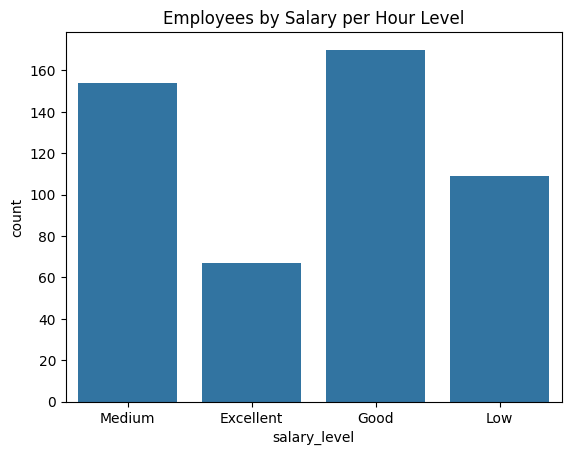

In [113]:


sns.countplot(x='salary_level', data=df)
plt.title("Employees by Salary per Hour Level")
plt.show()